# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [1]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle

import matplotlib.pyplot as plt 

from diffractsim import cm, mm, um 
import os

# from run_ga import compute_sorting_performance 

# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, fraction=0.05, pad=0.04, ax=ax[0])
    
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase,fraction=0.05, pad=0.04, ax=ax[1])
    plt.show()

    
# Let's get the Fresnel propagator in there to see what happens when we slightly perturb the knot/introduce a phase shift 

'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))

    
    return u2 

In [2]:
def compute_sorting_performance(phase_maps, list_of_OAMs):
    # Now, this is the fitness parameter 

    sorting_performance = 0  
    
    # Actually, let's introduce the crosstalk matrix 
    
    crosstalk_matrix = np.zeros((2,2))

    for ii in range(len(list_of_OAMs)):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 
        
        # Do a proper normalization on the incident field 
        
        field = norm_field(field,h)
        
        # Compute the initial field intensity. This will be important for later
        
        int_knot = np.sum(np.abs(field)**2)
    
        # modulate the field by the first phase map 

        field_mod_1 = field*phase_maps[0]

        # let's simulate the propagation of the lens
        if (simulateLens):
            field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
        else: # Take the fourier transform 
            field_lens = fftshift(fft2(field_mod_1))
        
        # What happens next depends on whether we have one or two phase maps
        
        if(num_of_phase_maps==1):
            # Compute the field intensity 
            final_field = field_lens
        else:
            # modulate the field by the second phase map 
            field_mod_2 = field_lens*phase_maps[1]
            # simulate the lens field again. This is the final field. 
            if (simulateLens):
                field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
            else: 
                field_lens_2 = ifft2(ifftshift(field_mod_2))
            # compute the field intensity 
            # field_lens_2 = field_lens_2/np.max(np.abs(field_lens_2))
            
            final_field = field_lens_2
            #final_field_int = np.abs(field_lens_2)**2
        
        # We normalize the final field and compute the intensity 
        final_field = norm_field(final_field,h)
        final_field_int = np.abs(final_field)**2
        
        # Define full set of indices, as you would summing through a for loop
        full_index = np.arange(len(output_chans))   
        # Delete ii from the list of full_index, creating a new temporary array
        temp_index = np.delete(full_index, ii)
        # Sum up the "incorrect" channels 
        incorrect_chans = 0
        
        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chans += np.sum(field_in_pupil)
            
        # Now, evaluate the sorting performance 
        correct_chans = np.sum(final_field_int*output_chans[ii])
        sorting_performance += correct_chans - incorrect_chans
        
        # Compute the detector effeciency 
        detect_eff = correct_chans/int_knot 
        crosstalk_matrix[ii,ii] = detect_eff 
        
        # Compute the crosstalk 
        crosstalk_eff = incorrect_chans/int_knot
        crosstalk_matrix[ii, (ii+1)%2] = crosstalk_eff 
        
    return sorting_performance, crosstalk_matrix

# Create field & modes of interest following yaml configuration

In [3]:
stream = open(f"configs/ga3.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 
num_of_phase_maps = cnfg['num_maps']
instance_name = cnfg['ga_instance'] # directory name of best phases

print(num_of_output_chans) 
# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']

# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)

# Propagation Distance 
prop_dist = 0

# Let's apply a rotation
rot_phi = cnfg['rot_angle']
#rot_op = np.exp(1j*rot_phi*phi)

#rot_phi=np.pi/4

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Apply rotation operator on coords 

# X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
# Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

xx,yy=np.meshgrid(X ,Y);

xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

r, phi= cart2pol(xx_rot,yy_rot)

''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []
#output_chans = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans, chan_sep=channel_seperation)
output_chans = output_chan_triangle(X, Y, output_chan_width, maxx, chan_sep=channel_seperation) # This can only be used if we are explcitly sorting three channels



if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
else:
    for ii in range(len(LG_modes)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = propTF(field, maxx, la, prop_dist)
        list_of_OAMs.append(oamModes(prop_dist, output_chans[ii]))
        

3


(-0.5, 127.5, 127.5, -0.5)

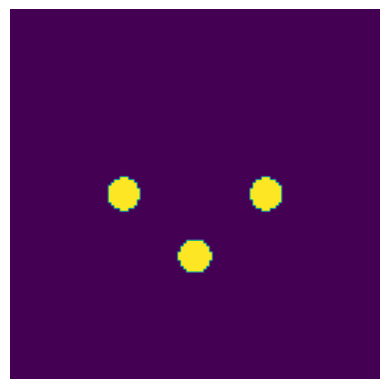

In [4]:
plt.imshow(output_chans[0] + output_chans[1] + output_chans[2])
plt.axis('off')

Create function which rotates the field

In [ ]:
def create_rotated_knots(rot_phi):
    
    # Apply rotation operator on coords. Update: The rotation should be 
    # X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
    # Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

    xx,yy=np.meshgrid(X ,Y);
    
    xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
    yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

    r, phi= cart2pol(xx_rot,yy_rot)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs


Create function which translates the field over x- and y- axis

In [ ]:
def create_translated_knots(x_trans, y_trans):

    xx,yy=np.meshgrid(X ,Y);
    
    xx_trans = xx + x_trans
    yy_trans = yy + y_trans 

    r, phi= cart2pol(xx_trans,yy_trans)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs

# to test

list_of_OAMs = create_translated_knots(0.0*mm, 0.0*mm)

Plot output channels

In [ ]:
# Let's properly normalize the field, instead of scaling it from 0 to 1

def norm_field(field,h):
    norm_fac=np.sqrt(np.sum(np.abs(field*h)**2))
    print(norm_fac)
    return field/norm_fac 

field = list_of_OAMs[1].oamBeam 
#field_2 = propTF(field,maxx,la,0.5*cm)
TotInt(field)

In [ ]:
field_fft = fftshift(fft2(field))
field_ifft = ifft2(ifftshift(field_fft))

plt.imshow(np.abs(field_ifft)**2)

In the paper by Fickler, they consider phase holograms ... "that modulate the beam by atleast 40 x 40 pixels" 

In [ ]:
count_x = 0
count_y = 0

# Here, we increment count_x because we are iterating in the horizontal direction 
for ii in range(N):
    for jj in range(N): 
        if(np.abs(field[ii,jj])**2 > 1e-10):
            count_x += 1

        
# Here, we increment count_y because we are iterating in the vertical direction 

for jj in range(N):
    for ii in range(N):
        if(np.abs(field[ii,jj])**2 > 1e-10):
            count_y += 1

    

Load genetic Instance

In [ ]:
import pickle

index = 1

#instance_name = 'knots_smaller_oneMap'

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)
        
print(instance_name)

In [ ]:
np.max(phase_out)

Compute phase screens and plot them 

In [ ]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=np.complex_)

GFilterStrength = 0

# Compute phase screens and plot them 
for ii in range(num_of_phase_maps):
    # Apply extra gaussian filter on output data 
    phase_out[ii] =sp.ndimage.gaussian_filter(phase_out[ii], sigma=maxx*GFilterStrength)
    phase_maps[ii]= np.exp(1j*phase_out[ii])

#phaseScreenDos = np.exp(1j*phase_out[1,:,:])
phase_screen=0
fig, ax = plt.subplots(1,1, figsize=(8,8))
first = ax.imshow(np.angle(phase_maps[phase_screen]), cmap='rainbow')
ax.set_title(f"Phase Screen {phase_screen+1}")
c1 = fig.colorbar(first, ax=ax)

plt.show()

In [ ]:
np.min(np.angle(phase_out))

Let's also consider an actual hologram here

In [ ]:
# This function generates phase gratings in reminisce of OAM gratings 

def OAMWithGratings(l,rows,cols,xoffset,yoffset,a):
    
    crow, ccol = int(rows / 2)+xoffset, int(cols / 2)+yoffset
    mask = np.zeros((rows,cols)) +0j
    fx = 10.0
    fy = 0.0
    phi = np.zeros((rows,cols))+0j

    for i in range (rows):
        for j in range (cols):
            
            x = i - crow
            y = j - ccol
            alpha = l*np.arctan2(x,y) + 2*np.pi*10*y/128
            g = a[0] + a[1]*np.cos(2*alpha)  + a[2]*np.cos(3*alpha) + a[3]*np.cos(4*alpha)
                  #g = 1/4*(1 + np.cos(alpha) + np.cos(2*alpha) +  np.cos(3*alpha)+np.cos(4*alpha))
                  #g = np.mod(alpha,2*np.pi)
            mask[i,j] = g
        
    return(mask)

test_mask = OAMWithGratings(1,N,N,0,0,[1,1,1,1])

Compute the propagation for each mode

In [ ]:
from scipy.fft import ifft2, ifftshift, fft2, fftshift
GFilterStrength = 0

# Let's pick an LG beam to analyze

mode_num = 0

field = list_of_OAMs[mode_num].oamBeam 
field = norm_field(field,h)

# Propagate the beam slightly using a Fresnel propagator 

field_2 = propTF(field,maxx, la, 0*cm)

# modulate the field by the first phase map 

field_mod_1 = field*phase_maps[0]

TotInt(field_mod_1)

# let's simulate the propagation of the lens

#field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
field_lens = fftshift(fft2(field_mod_1))
field_lens = norm_field(field_lens,h)

# compute the field intensity 

final_field_int = np.abs(field_lens)**2
final_final_field = sp.ndimage.gaussian_filter(final_field_int, sigma=maxx*GFilterStrength)

plt.imshow(final_final_field)
plt.colorbar()

In [ ]:
np.max(final_field_int)

Simulating the second phase map

In [ ]:
# modulate the field by the second phase map 

field_mod_2 = field_lens*phase_maps[1]

# simulate the lens field again. This is the final field. 

#field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
field_lens_2 = ifft2(ifftshift(field_mod_2))
TotInt(field_mod_2)
plt.imshow(abs(field_lens_2)**2)

# Compute the normalized sorting probability 

In [ ]:
simulateLens = False
sorting_performance, crosstalk_matrix = compute_sorting_performance(phase_maps, list_of_OAMs)

This is the algorithm that we use directly in this notebook

In [ ]:
sorting_performance = 0
correct_chans_list = []
total_chans_list = []
mean_prob_list = []

simulateLens = False

 # Now, this is the fitness parameter 

for ii in range(len(list_of_OAMs)):
    print("********")

    # Define initial OAM field and correct output channel 

    field = list_of_OAMs[ii].oamBeam 

    # Do a rough normalization on the incident field 

    field = norm_field(field,h)
    
    # Propagate the field using the Fresnel propagator 
    
    field = propTF(field, maxx, la, 0.0*cm)

    # modulate the field by the first phase map 

    field_mod_1 = field*phase_maps[0]

    # let's simulate the propagation of the lens
    if (simulateLens):
        field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
    else: # Take the fourier transform 
        field_lens = fftshift(fft2(field_mod_1))

    # What happens next depends on whether we have one or two phase maps

    if(num_of_phase_maps==1):
        # Compute the field intensity 
        final_field = field_lens
    else:
        # modulate the field by the second phase map 
        field_mod_2 = field_lens*phase_maps[1]
        # simulate the lens field again. This is the final field. 
        if (simulateLens):
            field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
        else: 
            field_lens_2 = ifft2(ifftshift(field_mod_2))
        # compute the field intensity 
        field_lens_2 = field_lens_2/np.max(np.abs(field_lens_2))

        final_field = field_lens_2
        #final_field_int = np.abs(field_lens_2)**2
        
    # Define full set of indices, as you would summing through a for loop
    full_index = np.arange(len(output_chans))   
    # Delete ii from the list of full_index, creating a new temporary array
    temp_index = np.delete(full_index, ii)
    # Sum up the "incorrect" channels 
    incorrect_chans = 0
    total_chans = 0
    # Compute the intensities of the field, but normalize first 
    final_field = norm_field(final_field,h)
    changee = norm_field(final_field,h)
    final_field_int = np.abs(final_field)**2
    #final_field_int = sp.ndimage.gaussian_filter(final_field_int, sigma=maxx*GFilterStrength)

    for ind in temp_index:
        
        field_in_pupil = final_field_int*output_chans[ind]
        incorrect_chans += np.sum(field_in_pupil)
        
    # Now, evaluate the sorting performance 
    
    correct_chans = np.sum(final_field_int*output_chans[ii])
    total_chans = correct_chans + incorrect_chans
    sorting_performance += correct_chans - incorrect_chans
    
 
    correct_chans_list.append(correct_chans)
    
    # Towards evaluating the sorting probability, we can get a naive estimate by computing the mean found over the channels
    mean_probability = correct_chans/total_chans
    mean_prob_list.append(mean_probability)
    print(mean_probability)
    print("******")
    
print(sorting_performance)
total_chans_list = np.array(total_chans_list)
correct_chans_list = np.array(correct_chans_list)

# Let's define a total score in terms of the mean probability 

print(np.mean(mean_prob_list))

Compute the crosstalk matrix

In [ ]:
plt.figure()
plt.imshow(crosstalk_matrix, vmin=0.0, vmax=1.0)
plt.colorbar()

print(crosstalk_matrix)
print(np.mean([crosstalk_matrix[0,0], crosstalk_matrix[1,1]]))
print(np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]]))

# Effect of Rotation on Hologram 

In [ ]:
rotate_angles = np.linspace(0, 2*np.pi, num=50)
mean_effs = []
mean_crosses = []

for angle in rotate_angles: 
    # Generate the rotated fields
    list_of_rotated_OAMs = create_rotated_knots(angle)
    # Compute the crosstalk matrix 
    simulateLens = False
    sorting_performance, crosstalk_matrix = compute_sorting_performance(phase_maps, list_of_rotated_OAMs)
    
    # Report the mean on the detector efficency, crosstalk. 
    #mean_eff = np.mean([crosstalk_matrix[0,0], crosstalk_matrix[1,1]])
    #mean_cross = np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]])
    
    mean_eff = crosstalk_matrix[0,0]
    mean_cross = crosstalk_matrix[1,0]
    
    mean_effs.append(mean_eff)
    mean_crosses.append(mean_cross)

In [ ]:
plt.plot(rotate_angles, mean_effs, label='Mean Efficiency')
plt.plot(rotate_angles, mean_crosses, label='Mean Crosstalk')
plt.legend()
plt.show()

# Effect of Translation on Field Performance

In [ ]:
x_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)
y_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)

effs = []
crosses = []

# How does the detector efficency and crosstalk change with the Trefoil? with the Cinquefoil? 

mode = 1 # 0 means trefoil, 1 means cinquefoil

for x_trans in x_translate:
    eff_row = []
    cross_row = []
    
    for y_trans in y_translate:
        
        # Generated the translated fields
        list_of_translated_OAMs = create_translated_knots(x_trans, y_trans)
        
        # Compute the crosstalk matrix
        simulateLens = False
        sorting_performance, crosstalk_matrix = compute_sorting_performance(phase_maps, list_of_translated_OAMs)
        
        # Extract the desired crosstalk/detector efficency 
        eff_row.append(crosstalk_matrix[mode,1])
        cross_row.append(crosstalk_matrix[mode,0])
    
    effs.append(eff_row)
    crosses.append(cross_row)

Make a cool 3D plot because everyone likes 3D plots boy howdy

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

X_trans, Y_trans = np.meshgrid(x_translate, y_translate)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X_trans, Y_trans, np.array(effs), cmap='viridis')
ax.set_xlabel('X Translation (m)')
ax.set_ylabel('Y Translation (m)')
ax.set_zlabel('Detector Efficency')
ax.set_title('Detector Efficency Evolution for Cinquefoil')
ax.set_zlim([0, 0.5])

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_trans, Y_trans, np.array(crosses), cmap='viridis')
ax2.set_xlabel('X Translation (m)')
ax2.set_ylabel('Y Translation (m)')
ax2.set_zlabel('Crosstalk')
ax2.set_title('Crosstalk Evolution for Cinquefoil')
ax2.set_zlim([0, 0.1])